# Stochastic Gradient Descent (SGD)

Unlike full-batch optimization, which computes averages across an entire dataset, SGD updates parameters iteratively using the localized error of a single, randomly selected data point.

---

### 1. The Stochastic Machine Learning Notation

Let our training dataset consist of $m$ individual observations. Instead of evaluating the entire collection simultaneously, SGD isolates a single, randomly sampled example at step $t$:
$$\left(X^{(i)}, y^{(i)}\right)$$

Where:
* $i \in \{1, 2, \dots, m\}$ represents the specific, randomly selected row index from the dataset.
* $X^{(i)}$ is the scalar input feature for that single row.
* $y^{(i)}$ is the continuous ground-truth target label for that single row.

Our parametric prediction framework maps this single input to an estimated output via the hypothesis function:
$$y_{\text{pred}}^{(i)} = w X^{(i)} + b$$

Where:
* $w$ (Weight): The slope parameter dictating the directional impact of $X$.
* $b$ (Bias): The intercept parameter establishing the baseline response when $X=0$.

---

### 2. The Localized Stochastic Cost Function

In a pure stochastic framework, we do not optimize using the overall Mean Squared Error (MSE) summation formula. Instead, we compute the instantaneous squared error for **only the chosen $i$-th row**. This localized loss is designated as $J_{\text{single}}(w, b)$:

$$J_{\text{single}}(w, b) = \left( y_{\text{pred}}^{(i)} - y^{(i)} \right)^2$$

Substituting our hypothesis definition yields the explicit cost equation for our single selected house or data point:
$$J_{\text{single}}(w, b) = \left( (w X^{(i)} + b) - y^{(i)} \right)^2$$

---

### 3. Calculus Derivation of SGD Gradients

To update our weight ($w$) and bias ($b$) instantly after analyzing our single row, we use calculus partial derivatives. We apply the **Chain Rule**: $\frac{\partial}{\partial \theta} [f(g(\theta))] = f'(g(\theta)) \cdot g'(\theta)$ to find the instantaneous slope of this single-point error.

#### A. Derivation for the Weight Gradient ($dw$)
We differentiate the single-row cost function with respect to our slope parameter $w$:
$$\frac{\partial J_{\text{single}}}{\partial w} = \frac{\partial}{\partial w} \left( (w X^{(i)} + b) - y^{(i)} \right)^2$$

1. Apply the power rule. Bring the exponent $2$ to the front, leaving the inner terms untouched:
   $$\frac{\partial J_{\text{single}}}{\partial w} = 2 \cdot \left( (w X^{(i)} + b) - y^{(i)} \right) \cdot \frac{\partial}{\partial w} \left( w X^{(i)} + b - y^{(i)} \right)$$

2. Compute the derivative of the inner function with respect to $w$. Because $b$ and $y^{(i)}$ act as independent static constants relative to $w$, their derivatives evaluate to zero. The derivative of $w X^{(i)}$ with respect to $w$ isolates the feature value:
   $$\frac{\partial}{\partial w} \left( w X^{(i)} + b - y^{(i)} \right) = X^{(i)} + 0 - 0 = \mathbf{X^{(i)}}$$

3. Combine these terms to find our final analytical weight gradient variable, $dw$:
   $$dw = \frac{\partial J_{\text{single}}}{\partial w} = 2 \cdot X^{(i)} \cdot \left( (w X^{(i)} + b) - y^{(i)} \right)$$

---

#### B. Derivation for the Bias Gradient ($db$)
We differentiate the same single-row cost function with respect to our intercept parameter $b$:
$$\frac{\partial J_{\text{single}}}{\partial b} = \frac{\partial}{\partial b} \left( (w X^{(i)} + b) - y^{(i)} \right)^2$$

1. Apply the power rule identically:
   $$\frac{\partial J_{\text{single}}}{\partial b} = 2 \cdot \left( (w X^{(i)} + b) - y^{(i)} \right) \cdot \frac{\partial}{\partial b} \left( w X^{(i)} + b - y^{(i)} \right)$$

2. Compute the derivative of the inner function with respect to $b$. Here, $w$, $X^{(i)}$, and $y^{(i)}$ all act as static constants relative to $b$, dropping to zero. The derivative of $b$ with respect to itself evaluates to a clean constant of 1:
   $$\frac{\partial}{\partial b} \left( w X^{(i)} + b - y^{(i)} \right) = 0 + 1 - 0 = \mathbf{1}$$

3. Combine these terms to find our final analytical bias gradient variable, $db$:
   $$db = \frac{\partial J_{\text{single}}}{\partial b} = 2 \cdot \left( (w X^{(i)} + b) - y^{(i)} \right)$$

---

### 4. The Parameter Update Math (The Core Loop Intuition)

Now that we have derived the instantaneous slopes $dw$ and $db$, the SGD algorithm alters the parameter coordinates immediately. Because a positive gradient points *up* the error slope, we use a subtraction sign to guide our weights downhill toward the lowest point of the local curve:

$$w := w - \alpha \cdot dw \implies w := w - \alpha \cdot \left[ 2 \cdot X^{(i)} \cdot \left( (w X^{(i)} + b) - y^{(i)} \right) \right]$$

$$b := b - \alpha \cdot db \implies b := b - \alpha \cdot \left[ 2 \cdot \left( (w X^{(i)} + b) - y^{(i)} \right) \right]$$

Where **$\alpha$ (Alpha)** represents the **Learning Rate**. 

#### Theoretical Summary: Why SGD Bounces
Because every individual training row has its own unique measurement noise, each localized step pulls the parameters in a slightly different direction. This causes the parameter updates to bounce around volatilely during training. However, because the average of these individual single-row vectors points down the global cost hill, the algorithm is mathematically guaranteed to navigate successfully toward the exact same minimum as full-batch methods.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

(100,)


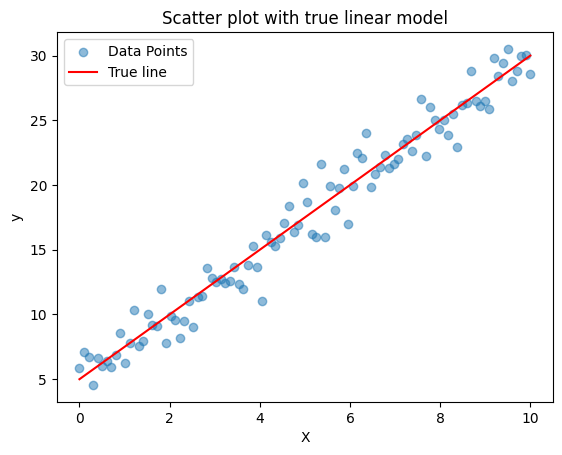

In [2]:
# ======================================================
# MODULE : 1 GENRATING RANDOM FEAURES(X) AND TARGET(y) 
# ======================================================

np.random.seed(46)#To get the same values every time
X = np.linspace(0,10,100)# 100 values starting from 0 to 10

#Setting the actual parameters
t_w,t_b= 2.5,5.0

#Adding random noise
noise=np.random.normal(0,1.5,size=len(X))

#Target y values 
y = t_w*X + t_b + noise 

print(X.shape)
#visualising feature X and target Y
plt.scatter(X,y,alpha=0.5,label='Data Points')
plt.plot(X, t_w*X + t_b, color='red',label='True line')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Scatter plot with true linear model')
plt.legend()
plt.show() 

In [3]:
# ======================================
# MODULE : 2 GRADIENT & MSE LOSS
# ======================================

def gradient(X,y,y_pred):
    
    #Error in predicted y
    error = y_pred - y
    
    #GD w.r.t w
    dw = 2.0 * X * error
    
    #GD w.r.t b
    db = 2 * error 
    
    return dw,db 
    
def mse_loss(y,y_pred):
    
    return np.mean((y_pred - y)**2)
    
     
    

In [4]:
# ======================================================
# MODULE 3: THE STOCHASTIC GRADIENT DESCENT (SGD) LOOP
# ======================================================

def sgd(w_start , b_start , lr , epochs , m):
    w = w_start
    b = b_start
    loss_hist = []
    
    for epoch in range(1,epochs+1):
        
        #Randomizing the index 
        indices = np.arange(m)
        np.random.shuffle(indices)
        
        for indx in indices:
        
            current_x = X[indx]
            current_y = y[indx]
            
            #calulating single prediction
            y_pred = w*current_x + b 
            
            #calculating the gradients
            dw,db= gradient(current_x , current_y, y_pred)
            
            #updating the weights and bias
            w-=lr*dw
            b-=lr*db
            
            # Anti-crash check: If values turn into infinity or NaN, halt the updates instantly
            if np.isnan(w) or np.isinf(w) or np.isnan(b) or np.isinf(b):
                w, b = np.nan, np.nan
                break
            
        #Calculating the MSE after each Epoch
        all_predictions = (w * X )+b
        loss = mse_loss(y,all_predictions)
        loss_hist.append(loss)
        
        
        if np.isnan(w):
            # Fill remaining history with nan so graph ranges don't break
            loss_hist.extend([np.nan] * (epochs - len(loss_hist)))
            break
   
    return w,b,epoch,loss_hist          
        

        

--------------------------------------------------------------------------------
For Learning rate: 0.0001
converges slowly and may still be far from optimum after 50 iterations. (stable but slower convergence)
---- Training Is Complete -----
True Parameters : w = 2.5 and b = 5.0
SGD Estimated Parameters : w = 3.015 and b = 1.457
--------------------------------------------------------------------------------
For Learning rate: 0.01
Learning rate is good and model converges nicely. (good convergence)
---- Training Is Complete -----
True Parameters : w = 2.5 and b = 5.0
SGD Estimated Parameters : w = 2.487 and b = 4.919
--------------------------------------------------------------------------------
For Learning rate: 0.25
Learning rate is too high makes the model diverge. (unstable divergence)
---- Training Is Complete -----
True Parameters : w = 2.5 and b = 5.0
SGD Estimated Parameters : w = nan and b = nan
------------------------------------------------------------------------------

/tmp/ipykernel_1339/3557123821.py:20: RuntimeWarning: overflow encountered in square
  return np.mean((y_pred - y)**2)
/tmp/ipykernel_1339/3557123821.py:11: RuntimeWarning: overflow encountered in scalar multiply
  dw = 2.0 * X * error


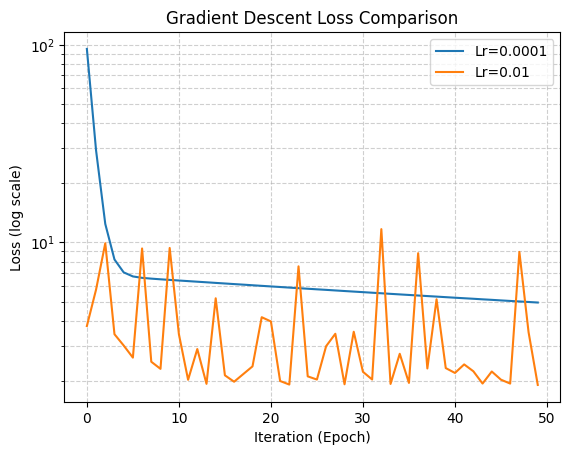

In [5]:

# =======================================================================
# MODULE 4: INITIALIZATION FOR TRAINING (CHECKING DIFFRENT LEARNING RATE)
# =======================================================================
learning_rate = [0.0001, 0.01, 0.25]
epochs = 50
m = len(X)

fig, ax = plt.subplots()
print("----" * 20)

for i in range(len(learning_rate)):
    w, b = 0.0, 0.0
    
    # Running model for different learning rate
    w_final, b_final, epoch_hist, loss_hist = sgd(w, b, learning_rate[i], epochs, m)
    
    print(f"For Learning rate: {learning_rate[i]}")
    

    if np.isnan(w_final) or np.isnan(b_final):
        print("Learning rate is too high makes the model diverge. (unstable divergence)")
        warnings.filterwarnings("ignore", category=RuntimeWarning) # Ignore warnings as w=nan, b=nan
        
    elif abs(t_w - w_final) < 1e-1 or abs(t_b - b_final) < 1e-1:
        # Note: Changed tolerance threshold from 1e-2 to 1e-1 to accommodate random noise variances
        print("Learning rate is good and model converges nicely. (good convergence)")
        ax.plot(range(epochs), loss_hist, '-', label=f"Lr={learning_rate[i]}")
        
    else:
        print(f"converges slowly and may still be far from optimum after {epoch_hist} iterations. (stable but slower convergence)")
        ax.plot(range(epochs), loss_hist, '-', label=f"Lr={learning_rate[i]}")        
        
    print("---- Training Is Complete -----")
    print(f"True Parameters : w = {t_w:.1f} and b = {t_b:.1f}")
    print(f"SGD Estimated Parameters : w = {w_final:.3f} and b = {b_final:.3f}")
    print("----" * 20)

ax.set_yscale('log')
ax.set_xlabel('Iteration (Epoch)')
ax.set_ylabel('Loss (log scale)')
ax.set_title('Gradient Descent Loss Comparison')
ax.grid(True, which='both', linestyle='--', alpha=0.6)
ax.legend()
plt.show()






## Mathematical Breakdown of the Four Convergence Scenarios

| Optimization Profile | Mathematical Mechanic | Visual & Structural Behavior |
| :--- | :--- | :--- |
| **1. Under-tuned / Too Small** <br>*(e.g., $\alpha = 0.0001$)* | $\alpha \ll \frac{1}{\lambda_{\max}}$ <br>*(Where $\lambda_{\max}$ is the maximum eigenvalue of the Hessian matrix).* | The parameter vector makes microscopic updates. The loss curve shows a slow, flat linear decline. It requires excessive computational cycles (epochs) to reach the minimum point, risking stagnation. |
| **2. Optimal / Just Right** <br>*(e.g., $\alpha = 0.01$)* | $\alpha \approx \frac{1}{\lambda_{\max}}$ | The step size matches the local curvature. The parameters slide rapidly down the steepest incline during early epochs and decelerate smoothly as the gradient shrinks near the valley floor. |
| **3. Over-tuned / Too Large** <br>*(e.g., Over-correcting)* | $\frac{1}{\lambda_{\max}} < \alpha < \frac{2}{\lambda_{\max}}$ | The steps are large enough to overshoot the valley center but remain bounded by the outer walls. The parameter vector cross-cuts the global minimum, causing the loss to oscillate back and forth. |
| **4. Unstable Divergence** <br>*(e.g., $\alpha = 0.25$)* | $\alpha > \frac{2}{\lambda_{\max}}$ | The step length lands the parameters higher up on the opposite wall of the paraboloid. Because the surface is steeper there, the next calculated gradient is even larger, triggering an exponential explosion. Weights rapidly hit infinity (`inf`) and collapse into `NaN`. |

---

### The Numerical Stability Principle (Why the Code Crashed)
In our experimental script, setting $\alpha = 0.25$ caused the weights to cascade into a classic **numerical overflow**. 
1. When updates overshoot aggressively, values scale up exponentially: $w \to 10^{38} \to 10^{308}$.
2. Once values surpass 64-bit floating-point limits (`float64`), your computer assigns them as positive/negative Infinity (`inf`).
3. The moment the loop attempts an algebraic operation with infinity (such as subtracting infinity from infinity: $\infty - \infty$), the processor loses tracking capability and outputs **`NaN` (Not a Number)**. 


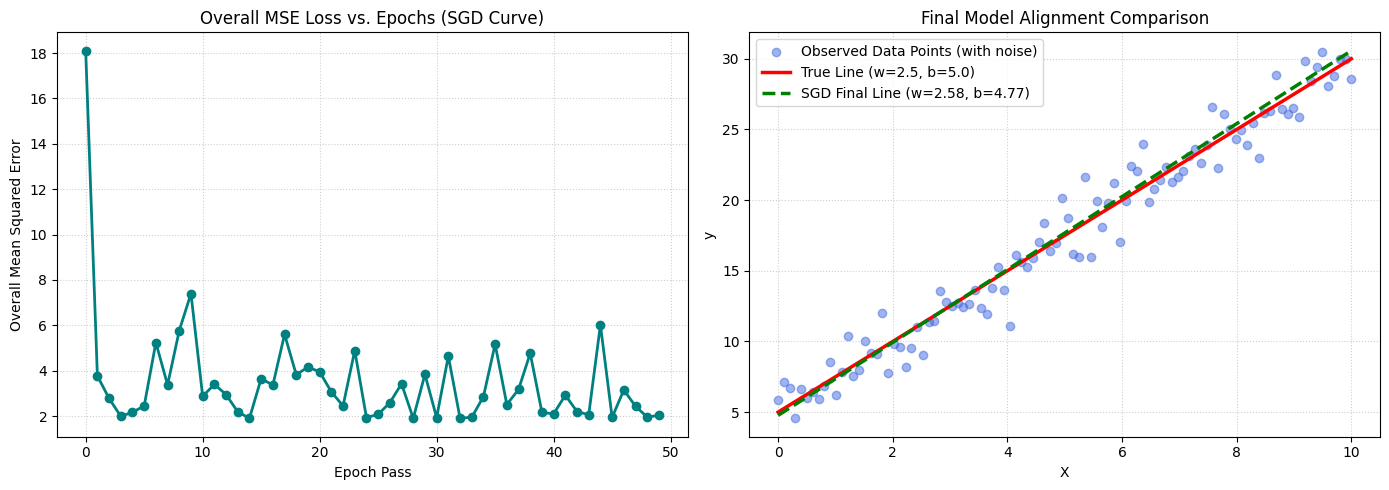

In [6]:

# ======================================================
# MODULE 5: VISUALIZING SGD CONVERGENCE & FINAL FIT
# ======================================================

#Change the value of learning rate to see the deivation and steps model takes 
learning_rate = 0.01


epochs = 50
m = len(X)

#initialising the weights and parameters
w, b = 0.0, 0.0

#Train the model 
w_final, b_final, epoch_hist, loss_hist = sgd(w, b, learning_rate, epochs, m)



#visualisation of model prediction and loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Loss Curve (Watching the error bowl drain)
ax1.plot(range(epochs), loss_hist, color='teal', marker='o', linewidth=2)
ax1.set_xlabel('Epoch Pass')
ax1.set_ylabel('Overall Mean Squared Error')
ax1.set_title('Overall MSE Loss vs. Epochs (SGD Curve)')
ax1.grid(True, linestyle=':', alpha=0.6)

# Plot B: Final Regression Fit against true underlying line
ax2.scatter(X, y, alpha=0.5, color='royalblue', label='Observed Data Points (with noise)')
ax2.plot(X, t_w*X + t_b, color='red', linewidth=2.5, label=f'True Line (w={t_w}, b={t_b})')
ax2.plot(X, w_final*X + b_final, color='green', linestyle='--', linewidth=2.5, label=f'SGD Final Line (w={w_final:.2f}, b={b_final:.2f})')
ax2.set_xlabel('X')
ax2.set_ylabel('y')
ax2.set_title('Final Model Alignment Comparison')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


#  Critical Edge Cases and Diagnostic Pitfalls

Linear regression assumes a clean, well-behaved dataset. When deployed in production environments, it faces several critical edge cases that can degrade its performance or break the underlying math:

### 1. High Multi-Collinearity (Feature Inter-dependence)
* **The Pitfall:** This happens when two or more input features are highly correlated (e.g., tracking a house's size in square feet and its size in square meters simultaneously).
* **The Impact:** The error bowl deforms into a flat, elongated trough. Gradient descent struggles to find the minimum, causing the parameters to oscillate wildly and making the calculated coefficients highly unstable.
* **The Fix:** Calculate the Variance Inflation Factor (VIF) and drop features with a VIF score greater than 5.

### 2. High Leverage Outliers
* **The Pitfall:** Because the loss function squares the errors, extreme anomalies exert a massive disproportionate "pull" on the regression line.
* **The Impact:** A single extreme outlier far away from the main cluster will cause the line to tilt toward it, ruining the model's accuracy for the rest of the dataset.
* **The Fix:** Implement robust regression metrics (like Huber Loss or MAE) or use Cook's Distance to isolate and prune high-leverage outliers before training.

### 3. Non-Linear Relationships (Underfitting Trap)
* **The Pitfall:** The data follows a curve (such as an exponential growth phase or a parabolic curve), but the model attempts to force a straight line through it.
* **The Impact:** The model underfits the data, leading to high training error and poor performance.
* **The Fix:** Transform your features into higher dimensions using **Polynomial Regression** (e.g., creating an $X^2$ feature) to let the linear model capture curved relationships.

### 4. Heteroscedasticity (Unbalanced Noise)
* **The Pitfall:** The variance of your data's noise changes across different ranges of $X$ (e.g., rich buyers vary widely in what they pay for large houses, while lower-income buyers stick to strict budgets for small houses).
* **The Impact:** This violates a core assumption of linear regression. While the line's direction remains accurate, your confidence intervals and error metrics become unreliable.
* **The Fix:** Apply a logarithmic or Box-Cox transformation to the target variable $y$ to stabilize the variance across the entire dataset.


# 🚀 Future Architectural Update: Implementing Concrete Engineering Protocols for Choosing $\alpha$

Stochastic Gradient Descent (SGD) is highly sensitive to the magnitude of the learning rate ($\alpha$). To move away from arbitrary trial-and-error tuning, our next development cycle will implement **Three Concrete Engineering Rules** to systematically discover, diagnose, and stabilize our model's parameter convergence.

---

#### 📐 Protocol 1: Geometric Logarithmic Grid Search (Discovery Phase)
Instead of searching for an optimal step size using small linear increments (e.g., $0.01, 0.02, 0.03$), we will implement a multi-magnitude geometric scan. This broad-scans the mathematical terrain by powers of $10$:

$$\alpha \in \{10^{-4}, 10^{-3}, 10^{-2}, 10^{-1}\} \implies \{0.0001, 0.001, 0.01, 0.1\}$$

* **Execution:** We will run a brief 5-epoch test for each magnitude profile. 
* **Boundary Localization:** If $\alpha = 0.01$ yields stable, downward cost trajectories while $\alpha = 0.1$ triggers numerical overflow (`inf`/`NaN`), we isolate our true operational boundary within that specific window. We will then perform a fine-grained linear search (e.g., testing $0.03$ or $0.05$) to maximize convergence speed.

---

#### 📈 Protocol 2: Loss Curve Diagnostics (Analysis Phase)
We will monitor the geometric profile of the validation loss curve across early training cycles. The geometry of the curve dictates our next hyperparameter adjustment:

### LR Diagnosis (Loss Curve)

**Too Small α** (Very slow, almost flat diagonal) → **Multiply by 10**  
**Just Right α** (Fast drop with smooth elbow) → **Lock & Maintain**  
**Too Large α** (Chaotic Zig-Zag or divergence) → **Divide by 2 or 3**



* **Divergence Guard:** If the loss vector trends upward exponentially, the safety audit will immediately halt execution to prevent numerical overflow, automatically cutting the learning rate by a factor of 10.

---

#### 📉 Protocol 3: Automated Learning Rate Time-Based Decay (Stabilization Phase)
Because pure SGD computes gradients using only one random observation at a time, keeping a fixed learning rate throughout training forces the parameters to bounce around the bottom of the error bowl indefinitely. 

To achieve smooth convergence, we will integrate a **Time-Based Decay Scheduler** into our core update loop. This dynamically reduces our stride length as the model gets closer to the minimum:

$$\alpha_{\text{epoch}} = \frac{\alpha_{\text{initial}}}{1 + d \cdot \text{epoch}}$$

Where:
* $\alpha_{\text{initial}}$: The verified starting learning rate discovered in Protocol 1.
* $d$: The decay coefficient (hyperparameter, typically set between $0.01$ and $0.1$).
* $\text{epoch}$: The current macro-iteration loop counter.

**Dynamic Result:** The model takes large, aggressive steps during early epochs when it is far from the target parameters, and automatically transitions to precise baby steps during later epochs to lock onto the global minimum without oscillating.


